<Figure size 1200x600 with 0 Axes>

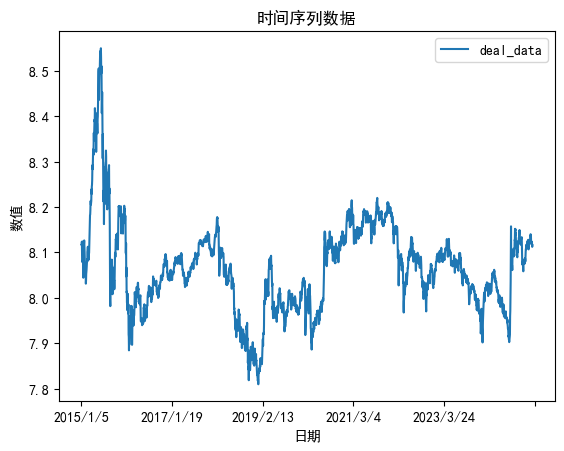

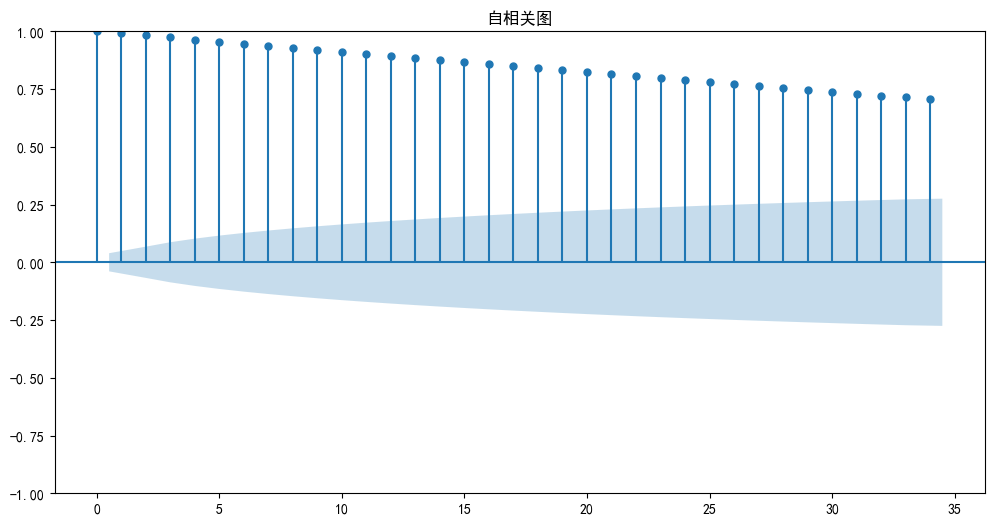

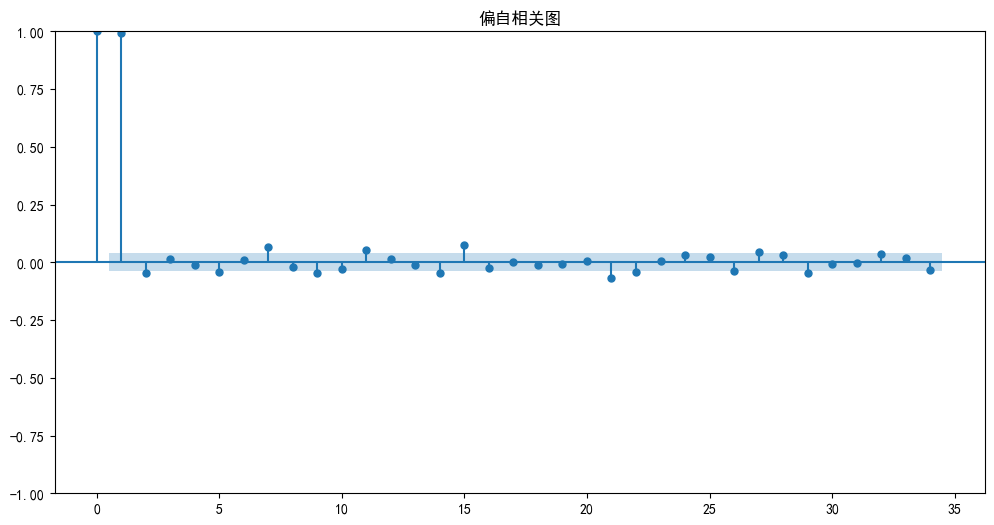

对数处理原始序列后，ADF检验结果为： (-3.2333948337616567, 0.018131224817121264, 27, 2461, {'1%': -3.4330099487687264, '5%': -2.8627151430515654, '10%': -2.5673955755408095}, -14478.887605427364)


In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller as ADF
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf #ACF与PACF
from statsmodels.tsa.arima.model import ARIMA #ARIMA模型
from statsmodels.graphics.api import qqplot  #qq图
from scipy import stats

df=pd.read_csv('../data/shangzheng_test.csv', encoding= 'GB2312')

# 更改列名
# df.rename(columns={'shangzheng_index': 'deal_data', 'Date': 'time_data'}, inplace=True)
# 设置索引
df.set_index(['time_data'], inplace=True)
data = df

# 对原始数据取对数
ts_data_log = np.log(data)

# 绘制时序图
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
# 绘制时序图
plt.figure(figsize=(12, 6))  # 设置图片大小为 12x6
#df['deal_data'].plot()
ts_data_log.plot()
plt.title('时间序列数据')
plt.xlabel('日期')
plt.ylabel('数值')
plt.show()

# 绘制自相关图
fig, ax = plt.subplots(figsize=(12, 6))
#plot_acf(df['deal_data'], ax=ax)
plot_acf(ts_data_log, ax=ax)
plt.title('自相关图')
plt.show()

# 绘制偏自相关图
fig, ax = plt.subplots(figsize=(12, 6))
#plot_pacf(df['deal_data'], ax=ax)
plot_pacf(ts_data_log, ax=ax)
plt.title('偏自相关图')
plt.show()

# 平稳性检测
print(u'对数处理原始序列后，ADF检验结果为：', ADF(ts_data_log))

#  平稳性检测过了  但一阶差分后效果更好

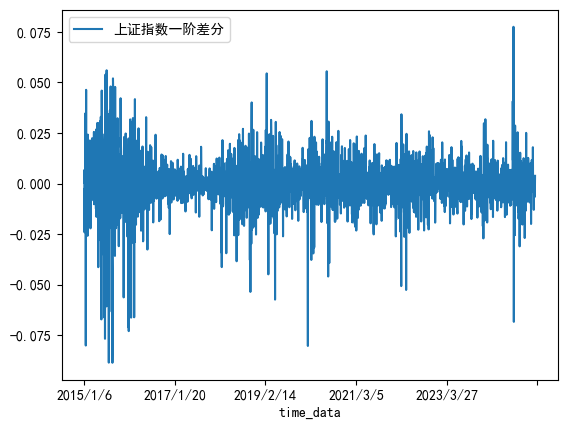

<Figure size 1000x600 with 0 Axes>

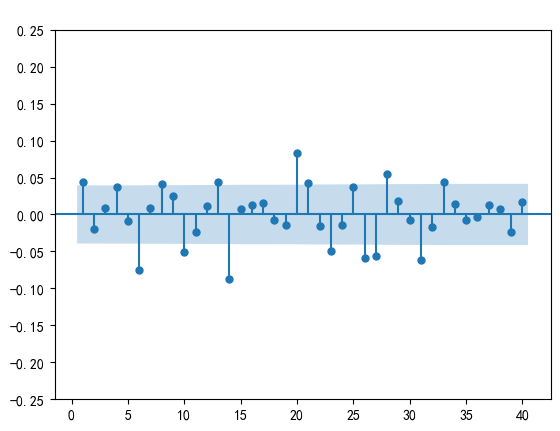

<Figure size 1000x600 with 0 Axes>

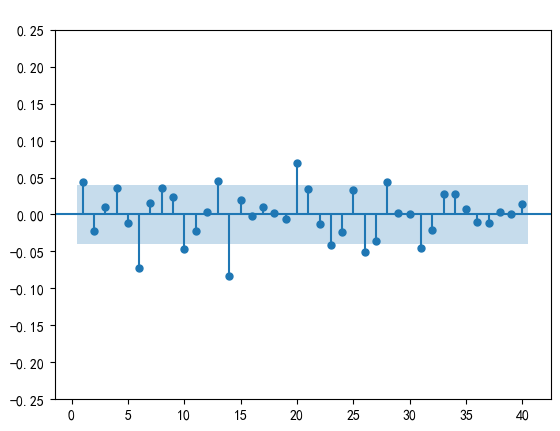

一阶差分序列的ADF检验结果为： (-9.488022713681092, 3.7172214097580015e-16, 27, 2460, {'1%': -3.4330110311801567, '5%': -2.862715621038473, '10%': -2.5673958300284223}, -14466.383450385198)


In [2]:
D_data = ts_data_log.diff().dropna()  #一阶差分
D_data.columns = [u'上证指数一阶差分']
# 时序图
D_data.plot()
plt.show()
plt.rcParams['axes.unicode_minus'] = False

# 绘制自相关图
plt.figure(figsize=(10, 6))
plot_acf(D_data, lags=40, zero=False)  # zero=False 去掉零阶
plt.title(u' ')
plt.ylim(-0.25, 0.25)
plt.yticks(np.arange(-0.25, 0.26, 0.05))  # 设置 y 轴刻度间隔为 0.05
plt.show()

# 绘制偏自相关图
plt.figure(figsize=(10, 6))
plot_pacf(D_data, lags=40, zero=False)
plt.title(u' ')
plt.ylim(-0.25, 0.25)
plt.yticks(np.arange(-0.25, 0.26, 0.05))
plt.show()

print(u'一阶差分序列的ADF检验结果为：', ADF(D_data[u'上证指数一阶差分']))  # 平稳性检测

#p值接近0  说明处理后数据稳定

#自动还是根据图像人工定阶呢    p和q取大一点 拟合效果更好 但会不会泛化差  R²直接1

In [4]:

print(u'差分序列的白噪声检验结果为：', acorr_ljungbox(D_data, lags=1))  # 返回统计量和p值       通过数据结果，说明不是白噪声


差分序列的白噪声检验结果为：     lb_stat  lb_pvalue
1  4.699782   0.030166


In [12]:
AIC = sm.tsa.stattools.arma_order_select_ic(D_data, max_ar=4, max_ma=4, ic='aic')['aic_min_order']
BIC = sm.tsa.stattools.arma_order_select_ic(D_data, max_ar=4, max_ma=4, ic='bic')['bic_min_order']

print('---AIC与BIC准则定阶---')
print('the AIC is{}\nthe BIC is{}\n'.format(AIC, BIC), end='')
p = BIC[0]
q = BIC[1]
diff_num = 1

#以上为自动定阶
#如果人工的话 可能6 1 6或者14 1 14

---AIC与BIC准则定阶---
the AIC is(2, 4)
the BIC is(2, 3)


In [5]:
import warnings
warnings.filterwarnings("ignore")

model = ARIMA(ts_data_log, order=(14, 1, 14)).fit()  # 建立ARIMA(p, d, q)模型

r_squared = 1 - (model.resid.var() / data.var())
print(f"R-squared: {r_squared}")

#为什么自动和人工都是1啊啊啊

R-squared: deal_data    1.0
dtype: float64


         lb_stat  lb_pvalue
1   4.538959e-07   0.999462
2   1.619097e-03   0.999191
3   2.365283e-02   0.999039
4   2.367539e-02   0.999930
5   3.578628e-02   0.999987
6   3.589512e-02   0.999999
7   3.657387e-02   1.000000
8   8.357629e-02   1.000000
9   8.667311e-02   1.000000
10  3.234020e-01   0.999999
11  3.419285e-01   1.000000
12  4.141851e-01   1.000000
13  4.146722e-01   1.000000
14  4.165517e-01   1.000000
15  4.183826e-01   1.000000
16  4.289523e-01   1.000000
17  4.360400e-01   1.000000
18  4.370713e-01   1.000000
19  4.444066e-01   1.000000
20  4.746549e-01   1.000000


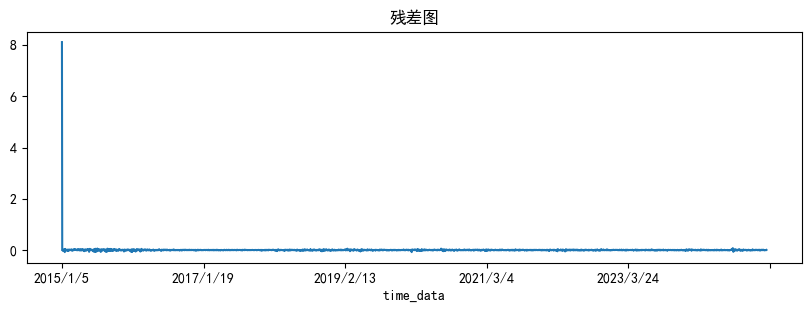

------------残差检验-----------
NormaltestResult(statistic=7888.885830088944, pvalue=0.0)


In [6]:
import warnings
warnings.filterwarnings("ignore")

model = ARIMA(ts_data_log, order=(14, 1, 14)).fit() 

from statsmodels.stats.diagnostic import acorr_ljungbox as lb_test
re = lb_test(model.resid, lags=20)
print(re)

#模型检验
def Model_checking(model):
    # 残差检验:检验残差是否服从正态分布，画图查看，然后检验
    # 绘制残差图
    model.resid.plot(figsize=(10, 3))
    plt.title("残差图")
    plt.show()

    print('------------残差检验-----------')
    # model.resid：残差 = 实际观测值 – 模型预测值
    print(stats.normaltest(model.resid))
    

Model_checking(model)